# Logistic Regression — Customer Churn Prediction (Telco)

Linear baseline for the churn problem. Every other model in this workshop is
compared against it, so the protocol below is deliberately the same one used in
the Random Forest, XGBoost and Neural Network notebooks:

1. **Preprocessing** — feature selection, feature engineering, encoding, scaling.
2. **Model definition** — a factory that builds the estimator from a parameter dict.
3. **Search space** — which hyper-parameters Optuna is allowed to move.
4. **Objective function** — mean out-of-fold average precision across 5 folds.
5. **Study** — the actual search.
6. **Threshold selection** — chosen on out-of-fold probabilities, never on test.
7. **Final training** — refit on the whole training set.
8. **Evaluation** — held-out test set.

This notebook is self-contained: it does not import anything from `src/`.

## 1. Imports and global settings

A single seed is reused everywhere (split, sampler, estimator) so the notebook is
reproducible. Optuna's own logging is silenced because the progress bar already
reports what matters.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)

SEED = 42
N_SPLITS = 5
N_TRIALS = 50
TEST_SIZE = 0.2

np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"pandas {pd.__version__}")


/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 3.0.6


## 2. Load and preprocess the dataset

The full pipeline (feature selection, service engineering, cleaning,
encoding, train/test split and standardisation) lives in
`PreprocessingTelco`, so the notebook only consumes the ready-to-model
splits.


In [4]:
from pathlib import Path
import sys

for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "w1_supervized_learning").is_dir():
        sys.path.insert(0, str(parent))
        break
else:
    raise ModuleNotFoundError("Could not locate the src directory")

from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)

prep = PreprocessingTelco()
X_train, X_test, y_train, y_test = prep.preprocess()
FEATURE_NAMES = prep.feature_names

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print(f"Train: {X_train.shape}  churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}  churn rate {y_test.mean():.1%}")


Train: (5625, 22)  churn rate 26.6%
Test:  (1407, 22)  churn rate 26.6%


## 3. Model definition

A factory rather than a single instance, because the search needs a *fresh*
untrained model on every fold of every trial.

Two settings stay fixed:

- **`solver="saga"`** is the only solver supporting all three penalties (L1, L2
  and elastic net), which lets the penalty itself become a tuned choice.
- **`max_iter=5000`** because `saga` converges slowly; the default of 100 would
  stop early and produce convergence warnings instead of a fitted model.

In [5]:
def build_model(params: dict) -> LogisticRegression:
    """Return an unfitted logistic regression with the given hyper-parameters."""
    return LogisticRegression(
        solver="saga",
        max_iter=5000,
        random_state=SEED,
        **params,
    )


build_model({"penalty": "l2", "C": 1.0, "class_weight": None})

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ra

## 4. Hyper-parameter search space

- **`penalty`** — L1 drives coefficients to exactly zero (implicit feature
  selection), L2 shrinks them smoothly, elastic net interpolates.
- **`C`** — inverse regularisation strength, sampled on a log scale because what
  matters is its order of magnitude, not its absolute value.
- **`class_weight`** — `"balanced"` reweights the loss by inverse class
  frequency, which usually buys recall on the minority (churn) class at some
  cost in precision. Letting Optuna choose avoids assuming the answer.
- **`l1_ratio`** — only meaningful for elastic net, so it is sampled
  conditionally. Optuna handles conditional parameters natively.

In [6]:
def suggest_params(trial: optuna.Trial) -> dict:
    """Sample one hyper-parameter configuration."""
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])

    params = {
        "penalty": penalty,
        "C": trial.suggest_float("C", 1e-3, 1e2, log=True),
        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced"]
        ),
    }

    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    return params

## 5. Objective function

**Why average precision and not accuracy or F1?**

Accuracy is useless here: predicting "nobody churns" already scores ~73%. F1 and
accuracy also depend on a decision threshold, and the threshold is not tuned yet
at this stage — optimising them would entangle two separate decisions. Average
precision summarises the whole precision-recall curve, so it measures how well
the model *ranks* customers by churn risk, independently of where the cut lands.

**Why report fold by fold?** `trial.report` plus `should_prune` lets Optuna's
`MedianPruner` abandon a clearly bad configuration after 2 or 3 folds instead of
paying for all 5, which roughly doubles the number of trials for the same budget.

In [7]:
def objective(trial: optuna.Trial) -> float:
    """Mean out-of-fold average precision for one hyper-parameter configuration."""
    params = suggest_params(trial)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    scores: list[float] = []

    for step, (fold_train_idx, fold_valid_idx) in enumerate(cv.split(X_train, y_train)):
        model = build_model(params)
        model.fit(X_train[fold_train_idx], y_train[fold_train_idx])

        proba = model.predict_proba(X_train[fold_valid_idx])[:, 1]
        scores.append(average_precision_score(y_train[fold_valid_idx], proba))

        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

## 6. Run the study

`TPESampler` builds a probabilistic model of which regions of the space produced
good scores and samples from there, which is far more efficient than random or
grid search at this budget. It is seeded so the search is reproducible.

`MedianPruner(n_warmup_steps=1)` only starts pruning after the first fold, so no
trial is killed on a single unlucky fold.

In [8]:
study = optuna.create_study(
    study_name="logistic_regression_telco",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = dict(study.best_params)

print(f"Best CV average precision: {study.best_value:.4f}")
print("Best hyper-parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

completed = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\nTrials: {len(completed)} completed, {len(pruned)} pruned")

  0%|          | 0/50 [00:00<?, ?it/s]/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty=

Best CV average precision: 0.6585
Best hyper-parameters:
  penalty: elasticnet
  C: 0.5955014798459116
  class_weight: None
  l1_ratio: 0.9473181214419756

Trials: 50 completed, 0 pruned


## 7. Threshold selection on out-of-fold probabilities

`predict_proba` returns a probability; turning it into a decision needs a cut.
The default 0.5 is arbitrary and usually wrong on imbalanced data, where it
under-predicts the minority class.

The cut is chosen on **out-of-fold** predictions from `cross_val_predict`: every
probability comes from a model that did not see that row. Tuning the threshold on
the test set instead would be a second, subtler form of leakage — the test score
would no longer estimate performance on unseen data.

F1 is maximised as a compromise between catching churners (recall) and not
flooding the retention team with false alarms (precision).

In [9]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = cross_val_predict(
    build_model(best_params),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
oof_f1 = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thresholds]

best_threshold = float(thresholds[int(np.argmax(oof_f1))])
print(f"Best threshold: {best_threshold:.2f}  (OOF F1 = {max(oof_f1):.4f})")
print(f"F1 at the default 0.50: {f1_score(y_train, (oof_proba >= 0.5).astype(int)):.4f}")

/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 

Best threshold: 0.36  (OOF F1 = 0.6332)
F1 at the default 0.50: 0.5869


## 8. How sensitive is F1 to the threshold?

A flat curve around the optimum means the choice is robust; a sharp peak means
the model is fragile and the threshold would need recalibrating in production.

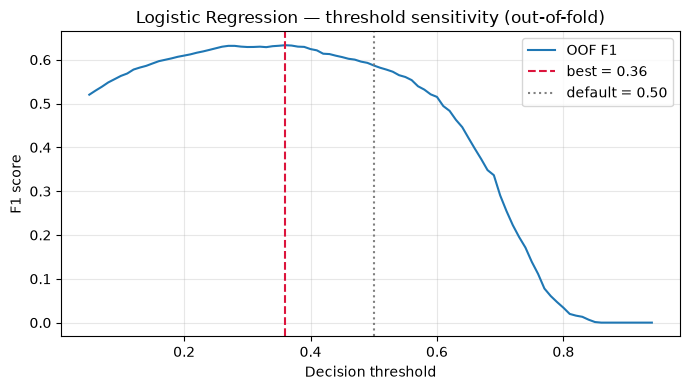

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, oof_f1, label="OOF F1")
ax.axvline(best_threshold, color="crimson", linestyle="--", label=f"best = {best_threshold:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", label="default = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("Logistic Regression — threshold sensitivity (out-of-fold)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Final training

Hyper-parameters and threshold are now fixed, both chosen using training data
only. The model is refitted on the **entire** training set: the folds existed to
estimate quality, and holding data back from the final fit would only waste it.

In [11]:
final_model = build_model(best_params)
final_model.fit(X_train, y_train)

non_zero = int(np.sum(final_model.coef_ != 0))
print(f"Fitted on {X_train.shape[0]} rows")
print(f"Non-zero coefficients: {non_zero} / {X_train.shape[1]}")

Fitted on 5625 rows
Non-zero coefficients: 18 / 22


/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## 10. Evaluation on the test set

The test set is touched exactly once, here.

Metrics are ordered from most to least informative for this problem.
`average_precision` and `roc_auc` judge the ranking and are threshold-free;
`f1`, `recall` and `precision` judge the decisions at the chosen cut.
**`accuracy` is last on purpose** — a model predicting "no churn" for everyone
scores ~73% here, so a high accuracy alone means nothing.

In [12]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

metrics = {
    "average_precision": average_precision_score(y_test, test_proba),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "f1": f1_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_preds),
    "accuracy": accuracy_score(y_test, test_preds),
}

print(f"Threshold used: {best_threshold:.2f}\n")
pd.Series(metrics, name="logistic_regression").to_frame().round(4)

Threshold used: 0.36



,logistic_regression
average_precision,0.6109
roc_auc,0.8326
f1,0.6145
recall,0.7139
precision,0.5394
balanced_accuracy,0.7466
accuracy,0.7619


## 11. Confusion matrix

The business reading of the two error types:

- **False negatives** — churners the model missed. Direct lost revenue.
- **False positives** — loyal customers flagged as at-risk. Cost of a wasted
  retention offer.

Which one hurts more depends on the margin per customer versus the cost of the
offer, and that is exactly the trade-off the threshold controls.

In [13]:
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual: stays", "actual: churns"],
    columns=["predicted: stays", "predicted: churns"],
)

,predicted: stays,predicted: churns
actual: stays,805,228
actual: churns,107,267


## 12. Which features drive the prediction?

This is the advantage of the linear baseline: the coefficients are directly
readable. Because every feature was standardised, they are on a comparable scale,
so their magnitude reflects relative importance.

A positive coefficient pushes towards churn, a negative one towards staying.

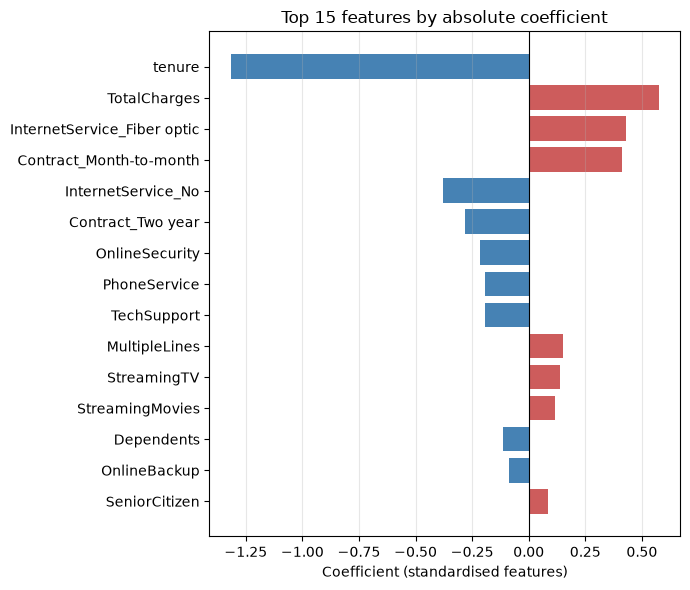

,coefficient
tenure,-1.3158
TotalCharges,0.5738
InternetService_Fiber optic,0.4280
Contract_Month-to-month,0.4117
InternetService_No,-0.3799
Contract_Two year,-0.2800
OnlineSecurity,-0.2163
PhoneService,-0.1943
TechSupport,-0.1938
MultipleLines,0.1535


In [14]:
coefficients = (
    pd.Series(final_model.coef_[0], index=FEATURE_NAMES, name="coefficient")
    .sort_values(key=abs, ascending=False)
)

top = coefficients.head(15)[::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color=["steelblue" if v < 0 else "indianred" for v in top.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardised features)")
ax.set_title("Top 15 features by absolute coefficient")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

coefficients.head(10).to_frame().round(4)

## 13. Notes and limitations

**What this notebook establishes.** A tuned linear baseline with an explicitly
chosen decision threshold, evaluated once on held-out data. Any more complex
model has to beat this to justify its cost.

**Limitations to keep in mind when comparing notebooks.**

- The threshold is tuned for F1. A different operating point (for example
  maximising recall subject to a precision floor) would change the decision
  metrics without changing `average_precision` or `roc_auc`.
- Logistic regression can only express linear boundaries in this feature space.
  It cannot capture interactions such as "fibre optic *and* month-to-month"
  unless they are engineered by hand — which is precisely where the tree
  ensembles have an edge.
- A single train/test split gives a point estimate. Repeating with several seeds
  would put error bars on these numbers.
